# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
# Cellule 1 - Imports (meme stack que l'article)
import sys
from pathlib import Path
import subprocess
import os
import datetime

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
print(tf.config.list_physical_devices("GPU"))  # should be []

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_citeulike_a_dataset, keep_top_k_tags, preprocess_text_nltk, text_length_stats
from src.experiment import prepare_train_test, run_all_models
from src.visualization import (
    plot_tag_distribution,
    plot_text_length_distributions,
    plot_model_metrics,
    plot_article_vs_current,
)
from src.results_save import save_metrics_enriched

# pd.set_option("display.max_colwidth", 120)

2026-04-16 15:28:35.222711: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 15:28:35.231170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 15:28:35.240344: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 15:28:35.243447: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 15:28:35.251063: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cellule 2 - Paramètres globaux
DATA_PATH = Path(PROJECT_ROOT / "data" / "citeulike-a")
if not os.path.exists(DATA_PATH):
    print("target =", DATA_PATH.resolve())
    print("exists =", DATA_PATH.exists())
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ["bash","-c", f"git clone https://github.com/js05212/citeulike-a.git data/citeulike-a"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {DATA_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
GLOVE_PATH = Path(PROJECT_ROOT / "data" / "glove.6B.300d.txt")
if not os.path.exists(GLOVE_PATH):
    print("target =", GLOVE_PATH.resolve())
    print("exists =", GLOVE_PATH.exists())
    if not GLOVE_PATH.exists():
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/glove.6B.zip \
            https://nlp.stanford.edu/data/glove.6B.zip"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/glove.6B.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {GLOVE_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
TOP_K_TAGS = 10
TEST_SIZE = 0.1
RANDOM_STATE = 42

In [3]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str | Path, top_k_tags: int = 10):
    df = load_citeulike_a_dataset(csv_path, normalize_tags=False)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

/workspace/data/citeulike-a/citations.dat
/workspace/data/citeulike-a/item-tag.dat
/workspace/data/citeulike-a/mult.dat
/workspace/data/citeulike-a/tags.dat
/workspace/data/citeulike-a/users.dat
/workspace/data/citeulike-a/vocabulary.dat


,title,abstract,tags,text,tag_list,processed_text,title_words,abstract_words,text_words,num_tags
0,The metabolic world of Escherichia coli is not...,To elucidate the organizational and evolutiona...,dissertation|metabolism|network|metabolic_netw...,The metabolic world of Escherichia coli is not...,"[network, review, networks]",metabolic world escherichia coli small elucida...,9,174,119,3
1,Reverse Engineering of Biological Complexity,Advanced technologies and biology have extreme...,behaviors|control|controllability|key--systems...,Reverse Engineering of Biological Complexity. ...,"[networks, network, review, evolution]",reverse engineering biological complexity adva...,5,123,82,4
2,Exploring complex networks,"The study of networks pervades all of science,...",scalefree|bistability|senior-project|complex-n...,Exploring complex networks. The study of netwo...,"[networks, statistics, network, review]",exploring complex network study network pervad...,3,99,63,4
3,Comparative assessment of large-scale data set...,Comprehensive protein protein interaction maps...,false|features|pin|network_confidence|ppi|two-...,Comparative assessment of large-scale data set...,"[networks, network, statistics, bioinformatics...",comparative assessment large scale data set pr...,9,61,50,5
4,Navigation in a small world,The small-world phenomenon â the principle t...,diktyology|complex-networks|filing-small-world...,Navigation in a small world. The small-world p...,"[networks, network, analysis]",navigation small world small world phenomenon ...,5,103,60,3


In [4]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
        "vocabulary_size" : len(set(" ".join(df["processed_text"]).split()))
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc,vocabulary_size
0,6397,10,8.882132,180.848835,1.802251,30799


/workspace/src/visualization.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


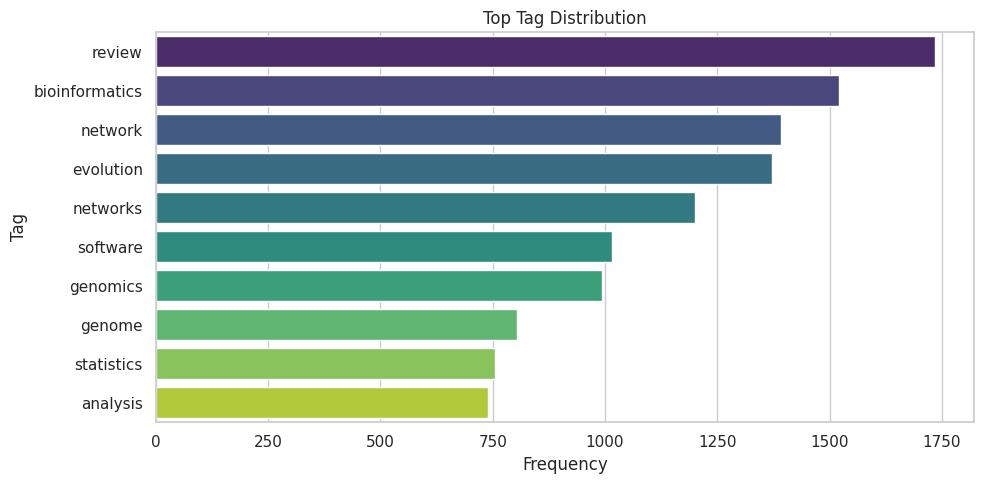

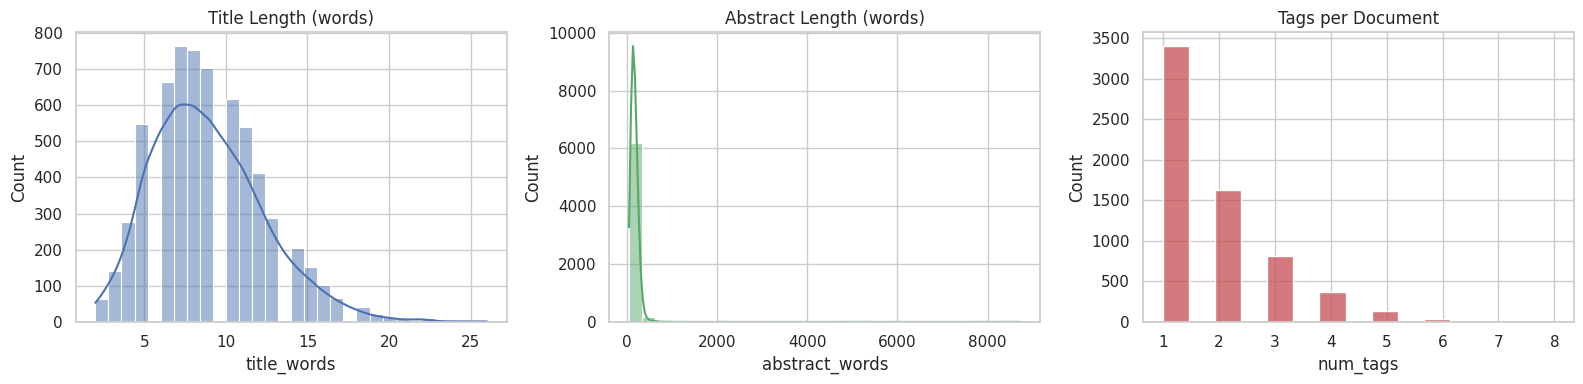

In [5]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig1 = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig2 = plot_text_length_distributions(df)
    plt.show()
    return fig1, fig2


_ = visualize_eda(df)

In [6]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_train, X_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_train), "Test:", len(X_test), "Labels:", len(mlb.classes_))

Train: 5757 Test: 640 Labels: 10


In [7]:
# Cellule 7 - Entraînement de tous les modèles
def train_models(X_train, X_test, y_train, y_test, n_topics: int, glove_path: str):
    return run_all_models(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
    )

# with tf.device("/CPU:0"):
metrics_df, predictions = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    n_topics=TOP_K_TAGS,
    glove_path=GLOVE_PATH,
)
metrics_df

I0000 00:00:1776353377.101714    1299 service.cc:146] XLA service 0x7fe9d004d5e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776353377.101727    1299 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1776353377.111585    1292 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


,name,micro_recall,micro_precision,micro_f1
0,SVM,0.537262,0.715935,0.613861
1,NB,0.757366,0.490736,0.595571
2,Paragraph Vector,0.540728,0.640657,0.586466
3,LDA,0.220971,0.629630,0.327133
4,Bi-GRU+Att,0.000000,0.000000,0.000000


In [8]:
# If you still have 'predictions' dict from the last run:
y_pred_bigru = predictions["Bi-GRU+Att"]

print("=== Bi-GRU+Att Diagnostic ===")
print(f"y_test shape: {y_test.shape}")
print(f"y_test pos rate: {y_test.mean():.4f}")
print(f"y_test avg labels/doc: {y_test.sum(axis=1).mean():.2f}")
print()
print(f"y_pred shape: {y_pred_bigru.shape}")
print(f"y_pred pos rate: {y_pred_bigru.mean():.4f}")
print(f"y_pred avg labels/doc: {y_pred_bigru.sum(axis=1).mean():.2f}")
print()

# If you can access raw probas (before thresholding), inspect them:
# Otherwise, these stats on binary preds are already very telling
print(f"Docs with 0 predicted tags: {(y_pred_bigru.sum(axis=1) == 0).sum()}")
print(f"Docs with >10 predicted tags: {(y_pred_bigru.sum(axis=1) > 10).sum()}")
print(f"Docs with >20 predicted tags: {(y_pred_bigru.sum(axis=1) > 20).sum()}")

=== Bi-GRU+Att Diagnostic ===
y_test shape: (640, 10)
y_test pos rate: 0.1803
y_test avg labels/doc: 1.80

y_pred shape: (640, 10)
y_pred pos rate: 0.0000
y_pred avg labels/doc: 0.00

Docs with 0 predicted tags: 640
Docs with >10 predicted tags: 0
Docs with >20 predicted tags: 0


In [ ]:
# Cellule 8 - Sauvegarde facultative des métriques
   
model_params = {
    "NB": {"vectorizer": "CountVectorizer", "max_features": 8000, "ngram_range": [1, 1], "threshold": 0.5},
    "SVM": {"vectorizer": "TfidfVectorizer", "max_features": 8000, "classifier": "LinearSVC", "threshold": 0.0},
    "LDA": {"num_topics": TOP_K_TAGS, "passes": 10, "iterations": 100, "threshold": 0.5},
    "Paragraph Vector": {"vector_size": 200, "window": 3, "epochs": 20, "threshold": 0.5},
    "Bi-GRU+Att": {"max_words": 15000, "max_len": 300, "gru_units": 25, "dense_units": 50, "dropout": 0.2, "epochs": 5, "batch_size": 64, "threshold": 0.5},
}

save_metrics_enriched(
    metrics_df=metrics_df,
    predictions=predictions,
    y_test=y_test,
    top_k_tags=TOP_K_TAGS,
    test_size=0.1,
    random_state=42,
    repeats=1,
    threshold=0.5,
    n_docs=len(df),
    n_unique_tags=len({t for tags in df["tag_list"] for t in tags}),
    avg_tags_per_doc=float(df["tag_list"].apply(len).mean()),
    glove_path=str(GLOVE_PATH),
    model_params=model_params,
    notes="first stable docker run",
)


(PosixPath('data/metrics_results_history_10.csv'), '6fb8339eca1f')

,name,micro_recall,micro_precision,micro_f1
0,SVM,0.537262,0.715935,0.613861
1,NB,0.757366,0.490736,0.595571
2,Paragraph Vector,0.540728,0.640657,0.586466
3,LDA,0.220971,0.629630,0.327133
4,Bi-GRU+Att,0.000000,0.000000,0.000000


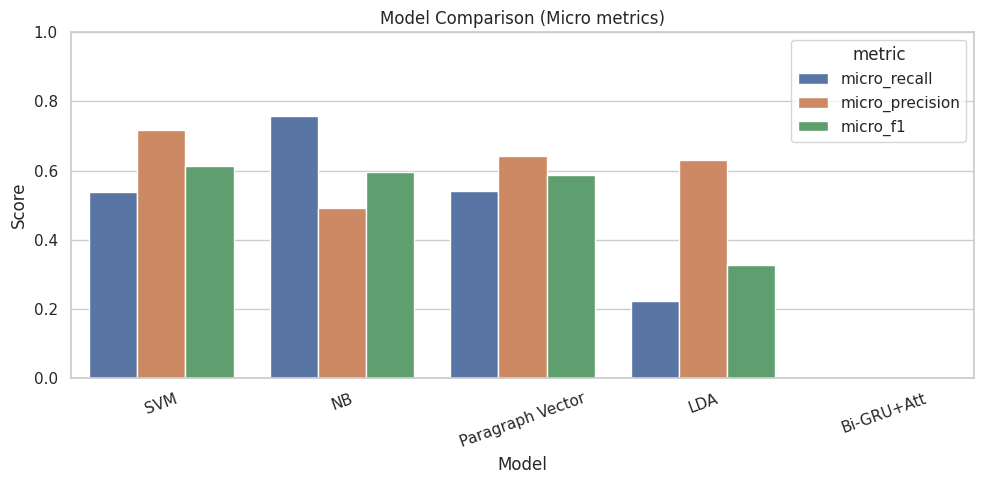

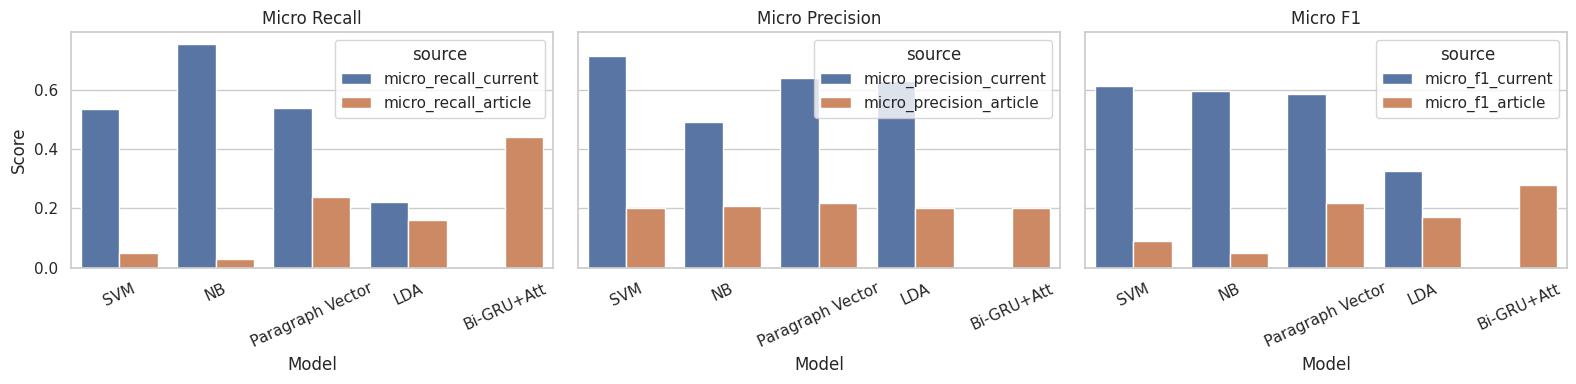

{'best_model': 'SVM', 'best_micro_f1': 0.6138613861386139}

In [10]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(metrics_df: pd.DataFrame):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
    }


summary = compile_and_compare(metrics_df)
summary